# Evaluating Variable Obfuscation on Perplexity and Self-preference in Code Review
<!-- 2026-07-11 -->

## Background

Language models are known to exhibit preference for their own model outputs while evaluating the quality of task completikon. This happens across [many different models](https://arxiv.org/abs/2506.02592), even when [objective criteria are given to inform judgment](https://arxiv.org/abs/2604.06996). [Self-refinement of LLM outputs](https://arxiv.org/abs/2402.11436) tends to amplify this self-preference bias. 

Some [work suggests](https://arxiv.org/abs/2410.21819v1) that lower perplexity from self-generated work may be a driver behind this self-preference. The perplexity of a given text to a model can be loosely understood to indicate how similar the text is to samples that the model saw during training. During language model training, high-perplexity tokens are used to update the weights to enable effective token prediction. Text generated by a given language model will naturally be lower-perplexity than text generated by a human or by a different language model. 

## AI Assisted Coding and Self-Preference

This self-preference presents an opportunity for improving AI-assisted coding. If a model generates, reviews, and refines its own output, the effects of self-preference may intefere with a model's ability to effectively complete coding tasks. In a [previous experiment](https://www.zacharyclement.com/posts/code_reviewing_performance), I saw clear self-preference effects resulting in lower recall rates of bugs detected by model self-generated outputs.

AI assisted coding is unique because is fairly easy to manipulate perplexity while retaining code functionality and correctness. Within a function, the spelling of local variable names and commented-out code can be changed while leaving core functionality (e.g. whether it completes a given task) intact. If self-preference can be manipulated by merely changing code perplexity, LLM-assisted coding harnesses can programmatically manipulate pieces of code that don't impact code logic to improve code review quality and self-improvement. 

## The current experiment

In this experiment, I will manipulate perplexity of given code outputs by generating high-perplexity strings from the hash of variable names and either appending those high-perplexity strings to the end of model outputs or replacing those high-perplexity strings. 

I will use an open-source language model (Qwen2.5-Coder-7B-Instruct) to validate that the hash-appending strategy actually increases code perplexity. Then, I will use gemini (which had high self-preference bias in our [previous experiment](https://www.zacharyclement.com/posts/code_reviewing_performance)) to evaluate whether increasing model perplexity reduces self-preference and makes a model more able to detect errors in its own logic. 


In [1]:
import os
import sys
from pathlib import Path

_pkg_dir = str((Path.cwd() / "code_reviewing_performance").resolve())
if _pkg_dir not in sys.path:
    sys.path.insert(0, _pkg_dir)

_prev_cwd = os.getcwd()
os.chdir(_pkg_dir)  # obfuscation_pipeline resolves "results/" relative to its own package dir
try:
    from obfuscation_pipeline import build_chunk_registry, transform_variants
    _chunk_registry = {c["chunk_id"]: c for c in build_chunk_registry()}
finally:
    os.chdir(_prev_cwd)


def show_chunk(problem_id: int, source: str, transform: str = "original") -> None:
    """Print a code chunk by problem number, source (claude/gpt/gemini/human), and transform."""
    chunk = _chunk_registry.get(f"{problem_id}:{source}")
    if chunk is None:
        print(f"No chunk for problem_id={problem_id}, source={source!r}. "
              "problem_id must be one of the problems where at least one generator "
              "failed; source one of "
              "claude/gpt/gemini/human.")
        return
    variant = next(v for v in transform_variants(chunk) if v["transform"] == transform)
    print(f"problem_id={problem_id}  source={source}  transform={transform}  is_correct={chunk['is_correct']}")
    print("-" * 70)
    print(variant["code"])


def show_problem(problem_id: int) -> None:
    """Print the original problem statement and its unit tests by problem number."""
    chunk = next((c for c in _chunk_registry.values() if c["problem_id"] == problem_id), None)
    if chunk is None:
        print(f"No problem for problem_id={problem_id}. "
              "problem_id must be one of the problems where at least one generator failed.")
        return
    problem = chunk["problem"]
    print(f"problem_id={problem_id}")
    print("-" * 70)
    print(problem["prompt"])
    print()
    print("Unit tests:")
    for test in problem["test_list"]:
        print(f"  {test}")







/Volumes/SanDisk/opt/anaconda3/envs/py_3_11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 378 problems (all)


In [2]:
show_problem(7)

problem_id=7
----------------------------------------------------------------------
Write a function to find all words which are at least 4 characters long in a string.

Unit tests:
  assert set(find_char_long('Please move back to stream')) == set(['Please', 'move', 'back', 'stream'])
  assert set(find_char_long('Jing Eco and Tech')) == set(['Jing', 'Tech'])
  assert set(find_char_long('Jhingai wulu road Zone 3')) == set(['Jhingai', 'wulu', 'road', 'Zone'])


In [3]:
show_chunk(473, "human", "original")

problem_id=473  source=human  transform=original  is_correct=True
----------------------------------------------------------------------

def tuple_intersection(test_list1, test_list2):
  return set([tuple(sorted(ele)) for ele in test_list1]) & set([tuple(sorted(ele)) for ele in test_list2])



In [4]:
show_chunk(7, "gpt", "original")

problem_id=7  source=gpt  transform=original  is_correct=False
----------------------------------------------------------------------
def find_char_long(text):
    """Return all whitespace-separated words with at least four characters."""
    return [word for word in text.split() if len(word) >= 4]


In [5]:
def trim_tuple(tuple_list, k):
    """
    Trim each tuple by removing k elements from both the start and end.
    
    Args:
        tuple_list: List of tuples to trim
        k: Number of elements to remove from each end
        
    Returns:
        List of trimmed tuples
        
    Example:
        >>> trim_tuples([(1, 2, 3, 4, 5), (10, 20, 30, 40)], 1)
        [(2, 3, 4), (20, 30)]
        
        >>> trim_tuples([(1, 2, 3, 4, 5)], 2)
        [(3,)]
    """
    return [t[k:-k] for t in tuple_list]

trim_tuple([(5, 3, 2, 1, 4), (3, 4, 9, 2, 1),(9, 1, 2, 3, 5), (4, 8, 2, 1, 7)], 2)


[(2,), (9,), (2,), (2,)]

In [6]:
show_chunk(7, "gemini", "original")

problem_id=7  source=gemini  transform=original  is_correct=False
----------------------------------------------------------------------
def find_char_long(text):
    """Finds all words in a string that are at least 4 characters long.

    Args:
        text (str): The input string containing words.

    Returns:
        list: A list of words with a length of 4 or more.
    """
    return [word for word in text.split() if len(word) >= 4]


## Results

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("code_reviewing_performance") / "results"


def load_phase(name: str) -> pd.DataFrame:
    return pd.DataFrame(json.loads((RESULTS_DIR / f"{name}.json").read_text()))


phase1 = load_phase("obfuscation_phase1")  # Qwen perplexity smoke test (2/50 problems)
phase2 = load_phase("obfuscation_phase2")  # Gemini self-preference x obfuscation (full run)
phase3 = load_phase("obfuscation_phase3")  # Baseline reviewers on human code, no obfuscation

# Same brand colors as the prior code-reviewing-performance post, plus a
# neutral color for the human/canonical-solution source.
BRAND_COLORS = {
    "claude": "#D97757",
    "sonnet": "#D97757",
    "gemini": "#4285F4",
    "gpt": "#74AA9C",
    "human": "#4A3AA7",
}

TRANSFORM_ORDER = ["original", "hash_append", "hash_replace"]
TRANSFORM_LABELS = {
    "original": "Original",
    "hash_append": "Hash appended",
    "hash_replace": "Hash replaced",
}


def style_axes(ax):
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

### Manipulation check: Does our hashed variable intetrvention increase perplexity? 

First, I verified that my proposed mechanism actually worked to increase code chunk perplexity. For both problem IDs I chose, and across all model sources, perplexity increased with hash-appended and hash-replaced variable names vs the baseline of the raw code chunk. 

Note that the sample size here is pretty small; I haven't quite talked myself into buying a GPU yet

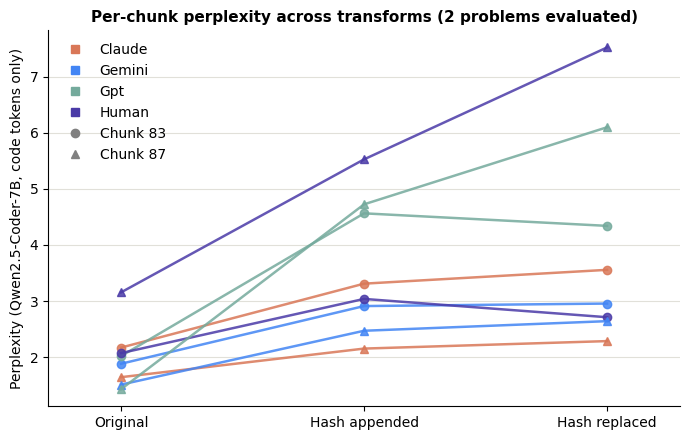

In [8]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 4.5))
transform_x = {t: i for i, t in enumerate(TRANSFORM_ORDER)}
CHUNK_MARKERS = {83: "o", 87: "^"}  # distinct marker per chunk_id
seen_sources: set[str] = set()
seen_chunks: set[int] = set()

for chunk_id, g in phase1.groupby("chunk_id"):
    chunk_num = int(chunk_id.split(":")[0])
    g = g.set_index("transform").reindex(TRANSFORM_ORDER)
    source = g["source"].iloc[0]
    marker = CHUNK_MARKERS.get(chunk_num, "x")  # fallback if unexpected chunk_id
    ax.plot(
        [transform_x[t] for t in TRANSFORM_ORDER], g["perplexity_raw"].values,
        color=BRAND_COLORS[source], marker=marker, markersize=6, linewidth=1.8,
        alpha=0.85,
    )
    seen_sources.add(source)
    seen_chunks.add(chunk_num)

ax.set_xticks(list(transform_x.values()))
ax.set_xticklabels([TRANSFORM_LABELS[t] for t in TRANSFORM_ORDER])
ax.set_xlim(-0.3, len(TRANSFORM_ORDER) - 0.7)
ax.set_ylabel("Perplexity (Qwen2.5-Coder-7B, code tokens only)")
ax.set_title("Per-chunk perplexity across transforms (2 problems evaluated)", fontsize=11, fontweight="bold")
style_axes(ax)

# Build one combined set of legend handles: source (color) entries + chunk (marker) entries
source_handles = [
    Line2D([0], [0], color=BRAND_COLORS[s], marker="s", linestyle="", markersize=6, label=s.capitalize())
    for s in sorted(seen_sources)
]
chunk_handles = [
    Line2D([0], [0], color="gray", marker=CHUNK_MARKERS[c], linestyle="", markersize=6, label=f"Chunk {c}")
    for c in sorted(seen_chunks)
]

ax.legend(handles=source_handles + chunk_handles, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

### Obfuscation and bug detection in self-generated code. 

Here, I used obfuscation 

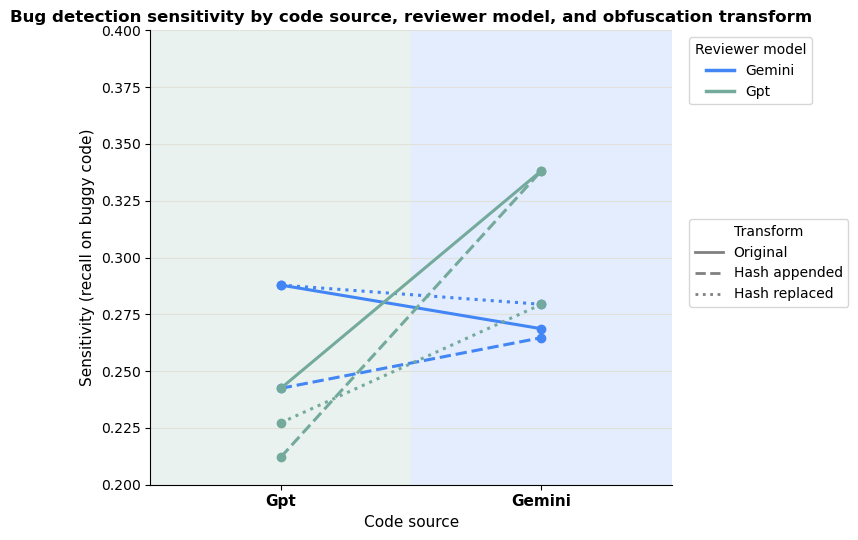

In [9]:
from matplotlib.lines import Line2D


def lighten(hex_color, amount=0.85):
    """Blend a hex color toward white. amount=0 -> no change, amount=1 -> white."""
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    r = r + (255 - r) * amount
    g = g + (255 - g) * amount
    b = b + (255 - b) * amount
    return (r / 255, g / 255, b / 255)


TRANSFORM_STYLES = {
    "original": "-",
    "hash_append": "--",
    "hash_replace": ":",
}

REVIEWER_ORDER = ["gemini", "gpt"]
SOURCE_ORDER = ["gpt", "gemini"]  # human excluded: too few human bugs (n=2) to be informative


def sensitivity_by_reviewer(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["bug_detected"].notna()].copy()
    valid["bug_detected"] = valid["bug_detected"].astype(bool)
    valid = valid[~valid["is_correct"]]  # sensitivity = recall on buggy code only
    return (
        valid.groupby(["source", "reviewer_model", "transform"])
        .agg(rate=("bug_detected", "mean"), n=("bug_detected", "size"))
        .reset_index()
    )

sensitivity2 = sensitivity_by_reviewer(phase2)

x_pos = {s: i for i, s in enumerate(SOURCE_ORDER)}

fig, ax = plt.subplots(figsize=(8, 5.5))

# Light background band per source column (same brand colors as elsewhere in the post)
for s in SOURCE_ORDER:
    ax.axvspan(x_pos[s] - 0.5, x_pos[s] + 0.5, color=lighten(BRAND_COLORS[s]), zorder=0)

# One line per reviewer_model x transform
for reviewer in REVIEWER_ORDER:
    for transform, ls in TRANSFORM_STYLES.items():
        sub = (
            sensitivity2[(sensitivity2["reviewer_model"] == reviewer) & (sensitivity2["transform"] == transform)]
            .set_index("source")
            .reindex(SOURCE_ORDER)
        )
        ax.plot(
            [x_pos[s] for s in SOURCE_ORDER],
            sub["rate"].values,
            color=BRAND_COLORS[reviewer],
            linestyle=ls,
            marker="o",
            markersize=6,
            linewidth=2.2,
            zorder=3,
        )

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([s.capitalize() for s in SOURCE_ORDER], fontsize=11, fontweight="bold")
ax.set_xlim(-0.5, len(SOURCE_ORDER) - 0.5)
ax.set_ylim(0.2, 0.4)
ax.set_ylabel("Sensitivity (recall on buggy code)", fontsize=11)
ax.set_xlabel("Code source", fontsize=11)
ax.set_title("Bug detection sensitivity by code source, reviewer model, and obfuscation transform", fontsize=12, fontweight="bold")
style_axes(ax)

model_handles = [Line2D([0], [0], color=BRAND_COLORS[m], lw=2.5, label=m.capitalize()) for m in REVIEWER_ORDER]
transform_handles = [
    Line2D([0], [0], color="gray", lw=2, linestyle=ls, label=TRANSFORM_LABELS[t])
    for t, ls in TRANSFORM_STYLES.items()
]

legend1 = ax.legend(handles=model_handles, title="Reviewer model", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.legend(handles=transform_handles, title="Transform", loc="upper left", bbox_to_anchor=(1.02, 0.6))
ax.add_artist(legend1)

fig.tight_layout()
plt.show()


In [10]:
sensitivity2

,source,reviewer_model,transform,rate,n
0,gemini,gemini,hash_append,0.264706,68
1,gemini,gemini,hash_replace,0.279412,68
2,gemini,gemini,original,0.268657,67
3,gemini,gpt,hash_append,0.338235,68
4,gemini,gpt,hash_replace,0.279412,68
5,gemini,gpt,original,0.338235,68
6,gpt,gemini,hash_append,0.242424,66
7,gpt,gemini,hash_replace,0.287879,66
8,gpt,gemini,original,0.287879,66
9,gpt,gpt,hash_append,0.212121,66


**Does obfuscation itself move sensitivity?** The chart above mixes source, reviewer, and transform together, so here's a logistic regression isolating the obfuscation effect: `bug_detected ~ transform + source + reviewer_model`, fit on the same buggy-code subset (`is_correct == False`, human source excluded), with standard errors clustered by `problem_id` since each problem contributes multiple rows. `transform` is dummy-coded against `original` as the reference level, so its coefficients are the obfuscation effect after controlling for source and reviewer.

In [11]:
import statsmodels.formula.api as smf


def fit_obfuscation_logit(df: pd.DataFrame, buggy: bool):
    valid = df[df["bug_detected"].notna()].copy()
    valid["bug_detected"] = valid["bug_detected"].astype(int)
    valid = valid[valid["source"].isin(SOURCE_ORDER)]
    valid = valid[~valid["is_correct"] if buggy else valid["is_correct"]]
    return smf.logit(
        "bug_detected ~ C(transform, Treatment('original')) + C(source) + C(reviewer_model)",
        data=valid,
    ).fit(cov_type="cluster", cov_kwds={"groups": valid["problem_id"]}, disp=False)


def odds_ratio_table(model) -> pd.DataFrame:
    conf = model.conf_int()
    conf.columns = ["ci_low", "ci_high"]
    return pd.DataFrame({
        "odds_ratio": np.exp(model.params),
        "ci_low": np.exp(conf["ci_low"]),
        "ci_high": np.exp(conf["ci_high"]),
        "p_value": model.pvalues,
    }).round(3)


sensitivity_model = fit_obfuscation_logit(phase2, buggy=True)
odds_ratio_table(sensitivity_model)


,odds_ratio,ci_low,ci_high,p_value
Intercept,0.442,0.276,0.707,0.001
"C(transform, Treatment('original'))[T.hash_append]",0.905,0.779,1.052,0.193
"C(transform, Treatment('original'))[T.hash_replace]",0.923,0.789,1.079,0.314
C(source)[T.gpt],0.797,0.492,1.292,0.358
C(reviewer_model)[T.gpt],1.009,0.674,1.510,0.966


### False positive rate under obfuscation

Sensitivity only looks at buggy code. The flip side is the false positive rate — how often a reviewer flags code that's actually correct — grouped and styled the same way as the sensitivity chart above.

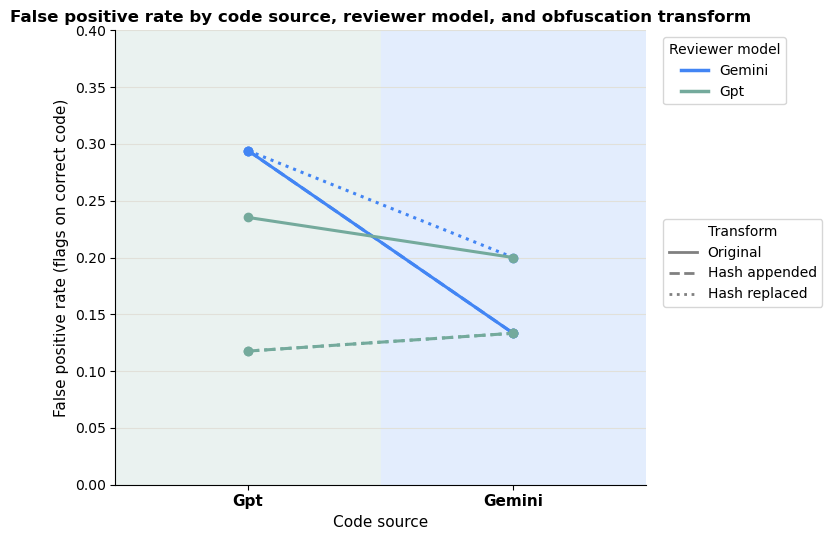

In [12]:
def fpr_by_reviewer(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["bug_detected"].notna()].copy()
    valid["bug_detected"] = valid["bug_detected"].astype(bool)
    valid = valid[valid["is_correct"]]  # false positive rate = flags on correct code
    return (
        valid.groupby(["source", "reviewer_model", "transform"])
        .agg(rate=("bug_detected", "mean"), n=("bug_detected", "size"))
        .reset_index()
    )


fpr2 = fpr_by_reviewer(phase2)

fig, ax = plt.subplots(figsize=(8, 5.5))

for s in SOURCE_ORDER:
    ax.axvspan(x_pos[s] - 0.5, x_pos[s] + 0.5, color=lighten(BRAND_COLORS[s]), zorder=0)

for reviewer in REVIEWER_ORDER:
    for transform, ls in TRANSFORM_STYLES.items():
        sub = (
            fpr2[(fpr2["reviewer_model"] == reviewer) & (fpr2["transform"] == transform)]
            .set_index("source")
            .reindex(SOURCE_ORDER)
        )
        ax.plot(
            [x_pos[s] for s in SOURCE_ORDER],
            sub["rate"].values,
            color=BRAND_COLORS[reviewer],
            linestyle=ls,
            marker="o",
            markersize=6,
            linewidth=2.2,
            zorder=3,
        )

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([s.capitalize() for s in SOURCE_ORDER], fontsize=11, fontweight="bold")
ax.set_xlim(-0.5, len(SOURCE_ORDER) - 0.5)
ax.set_ylim(0, 0.4)
ax.set_ylabel("False positive rate (flags on correct code)", fontsize=11)
ax.set_xlabel("Code source", fontsize=11)
ax.set_title("False positive rate by code source, reviewer model, and obfuscation transform", fontsize=12, fontweight="bold")
style_axes(ax)

legend1 = ax.legend(handles=model_handles, title="Reviewer model", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.legend(handles=transform_handles, title="Transform", loc="upper left", bbox_to_anchor=(1.02, 0.6))
ax.add_artist(legend1)

fig.tight_layout()
plt.show()


In [13]:
fpr2

,source,reviewer_model,transform,rate,n
0,gemini,gemini,hash_append,0.133333,15
1,gemini,gemini,hash_replace,0.200000,15
2,gemini,gemini,original,0.133333,15
3,gemini,gpt,hash_append,0.133333,15
4,gemini,gpt,hash_replace,0.133333,15
5,gemini,gpt,original,0.200000,15
6,gpt,gemini,hash_append,0.294118,17
7,gpt,gemini,hash_replace,0.294118,17
8,gpt,gemini,original,0.294118,17
9,gpt,gpt,hash_append,0.117647,17


**Effect of obfuscation on false positives.** Same regression as above, but fit on the correct-code subset (`is_correct == True`), so `bug_detected` here means a false-positive flag.

In [14]:
fpr_model = fit_obfuscation_logit(phase2, buggy=False)
odds_ratio_table(fpr_model)


,odds_ratio,ci_low,ci_high,p_value
Intercept,0.270,0.085,0.854,0.026
"C(transform, Treatment('original'))[T.hash_append]",0.737,0.467,1.164,0.191
"C(transform, Treatment('original'))[T.hash_replace]",0.821,0.546,1.237,0.346
C(source)[T.gpt],1.589,0.375,6.726,0.530
C(reviewer_model)[T.gpt],0.620,0.221,1.741,0.364


## Does review quality depend on whether the reviewer "understands" the problem?

A different explanation for weak bug-detection rates: maybe it's not about the code's
source at all, but about whether the *reviewer* model is capable of solving the
underlying problem in the first place. If a model can't solve a problem itself, it may
lack the understanding needed to catch bugs in *anyone's* solution to it.

This uses `results/results.csv` (the original 200-problem, 3-generator x 3-reviewer
study), restricted to the **cautious reviewer persona only** (`reviewer_persona ==
"persona_1"`; the creative-persona reviewer rows are dropped). For each reviewer model
and problem, "understood" is whether that same model, acting as *generator*, produced a
passing solution to that problem (`successful_run_pre_review`) — a proxy for whether the
model has the competence to solve it, independent of whose code it's reviewing. Broken
out by reviewer model, to check the pattern isn't driven by one model:

In [15]:
results = pd.read_csv(RESULTS_DIR / "results.csv")
results = results[results["reviewer_persona"] == "persona_1"].copy()
results = results[results["bug_detected"].notna()].copy()
results["bug_detected"] = results["bug_detected"].astype(bool)
results["is_correct"] = results["successful_run_pre_review"].astype(bool)

# "Understood" = did this reviewer model, acting as generator, solve this problem itself.
own_understanding = (
    results[results["generator_model"] == results["reviewer_model"]]
    [["reviewer_model", "problem_id", "successful_run_pre_review"]]
    .drop_duplicates()
    .rename(columns={"successful_run_pre_review": "reviewer_understood"})
)
results = results.merge(own_understanding, on=["reviewer_model", "problem_id"], how="left")


def understanding_rates(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby(group_cols):
        key = key if isinstance(key, tuple) else (key,)
        buggy, correct = g[~g["is_correct"]], g[g["is_correct"]]
        rows.append({
            **dict(zip(group_cols, key)),
            "sensitivity": buggy["bug_detected"].mean() if len(buggy) else float("nan"),
            "n_buggy": len(buggy),
            "false_positive_rate": correct["bug_detected"].mean() if len(correct) else float("nan"),
            "n_correct": len(correct),
        })
    return pd.DataFrame(rows)


UNDERSTOOD_COLORS = {True: "#2a78d6", False: "#898781"}
UNDERSTOOD_LABELS = {True: "Reviewer solved this problem itself", False: "Reviewer failed this problem itself"}

In [16]:
results.groupby('problem_id').agg(
    {'bug_detected': 'sum'}).reset_index().sort_values('bug_detected', 
ascending = False).reset_index().loc[0:40]

,index,problem_id,bug_detected
0,253,581,4
1,199,437,4
2,220,468,4
3,123,260,4
4,260,590,4
5,246,572,4
6,107,237,4
7,152,294,4
8,264,594,4
9,77,132,3


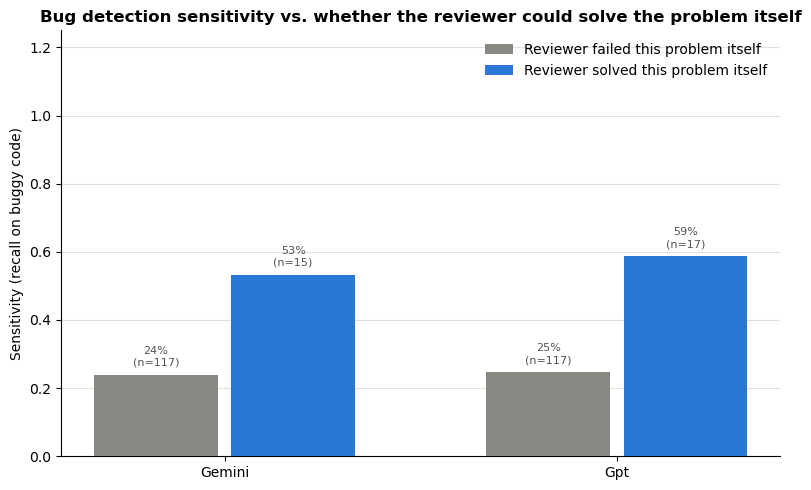

In [17]:
by_model = understanding_rates(results, ["reviewer_model", "reviewer_understood"])
reviewer_order4 = [ "gemini", "gpt"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(reviewer_order4))
bar_width = 0.35
for i, understood in enumerate([False, True]):
    offset = (i - 0.5) * bar_width
    sub = by_model[by_model["reviewer_understood"] == understood].set_index("reviewer_model").reindex(reviewer_order4)
    bars = ax.bar(x + offset, sub["sensitivity"].values, width=bar_width * 0.9,
                   color=UNDERSTOOD_COLORS[understood],
                   label=UNDERSTOOD_LABELS[understood], zorder=3)
    for bar, val, n in zip(bars, sub["sensitivity"].values, sub["n_buggy"].values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}\n(n={n:.0f})",
                     ha="center", va="bottom", fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in reviewer_order4])
ax.set_ylim(0, 1.25)
ax.set_ylabel("Sensitivity (recall on buggy code)")
ax.set_title("Bug detection sensitivity vs. whether the reviewer could solve the problem itself", fontsize=12, fontweight="bold")
style_axes(ax)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

> **Caveat.** This isn't a clean experiment — problem difficulty confounds it. A problem
> a reviewer "understood" (solved correctly itself) is disproportionately an *easy*
> problem, so it's also more likely that *every* generator's code on that problem is
> correct. That's why the "solved it themselves" bars above rest on far fewer buggy
> samples than the "didn't solve it" bars (see the `n=` labels) — easy problems simply
> generate few buggy chunks to test sensitivity on. Worth re-running as a
> per-problem-difficulty-controlled regression before leaning on this result.